# **Aula 07 — Fundamentos de Redes Neurais Artificiais**

## **Perceptrons, MLPs e treinamento por gradiente**

Esta aula introduz as ideias matemáticas e computacionais que sustentam as redes neurais artificiais tradicionais, em especial as redes **MLP** (*Multilayer Perceptrons*). O objetivo é entender o que uma rede calcula, como ela mede o erro e como ajusta seus parâmetros para aprender uma relação a partir de exemplos.

Ao final, o estudante deverá ser capaz de:

- identificar a estrutura de um perceptron e de uma MLP;
- distinguir pesos, vieses, camadas e funções de ativação;
- interpretar uma função de perda, em especial o MSE;
- explicar o papel da regra da cadeia, da retropropagação e da diferenciação automática;
- reconhecer o efeito da taxa de aprendizagem, da inicialização e do otimizador;
- diferenciar épocas, batches, iterações e passos de otimização.

## **1. Motivação: redes neurais como aproximadoras de funções**

Uma rede neural é, essencialmente, uma função parametrizada. Ela recebe uma entrada $\mathbf{x}$, realiza transformações sucessivas e produz uma previsão $\hat{\mathbf{y}}$:

$$
\hat{\mathbf{y}} = \mathcal{N}_{\boldsymbol{\theta}}(\mathbf{x}),
$$

em que $\boldsymbol{\theta}$ representa todos os parâmetros ajustáveis da rede: pesos e vieses.

Em uma regressão simples, por exemplo, podemos fornecer $x$ e pedir que a rede aproxime uma função conhecida:

$$
x \longrightarrow \text{MLP} \longrightarrow \hat{y}(x).
$$

No contexto posterior de transferência de calor, uma rede poderá receber posição e tempo e prever um campo de temperatura:

$$
(x,t) \longrightarrow \text{MLP} \longrightarrow \hat{T}(x,t).
$$

Nesta aula, o foco é a rede neural convencional. Os paralelos com problemas físicos aparecem apenas para mostrar que a mesma base matemática será reutilizada adiante.

> **Literatura Recomendada**  
Vídeo: [Statquest: Redes Neurais](https://youtu.be/CqOfi41LfDw?si=dHJxqUCnlWakDJqW)

---

## **2. O perceptron: um neurônio artificial**

O **perceptron** é a unidade elementar de uma rede neural. Ele combina as entradas de forma ponderada, adiciona um viés e aplica uma função de ativação:

$$
z = \sum_{i=1}^{n} w_i x_i + b,
$$

ou, em forma vetorial,

$$
z = \mathbf{w}^{\mathsf{T}}\mathbf{x}+b.
$$

Em seguida, a saída do neurônio é

$$
a = \phi(z).
$$

Aqui:

- $\mathbf{x}$ são as entradas;
- $\mathbf{w}$ são os pesos;
- $b$ é o viés (*bias*);
- $z$ é a combinação linear;
- $\phi$ é a função de ativação;
- $a$ é a saída do neurônio.

Os pesos controlam a influência relativa de cada entrada. O viés desloca a resposta do neurônio e permite que ele represente relações que não passam necessariamente pela origem.

## **3. Por que funções de ativação são necessárias?**

Sem uma função de ativação, cada camada seria apenas uma transformação linear. Mesmo empilhando várias camadas lineares, o resultado seria equivalente a uma única transformação linear:

$$
\mathbf{W}_2(\mathbf{W}_1\mathbf{x}+\mathbf{b}_1)+\mathbf{b}_2
= (\mathbf{W}_2\mathbf{W}_1)\mathbf{x} + (\mathbf{W}_2\mathbf{b}_1+\mathbf{b}_2).
$$

As ativações introduzem **não linearidade**. É isso que permite à rede aproximar relações mais ricas, como curvas, superfícies e campos que não podem ser descritos apenas por uma reta ou plano.

## **4. Funções de ativação mais comuns**

### **Sigmoid**

$$\sigma(z)=\frac{1}{1+e^{-z}}.$$

Produz valores entre $0$ e $1$. É útil principalmente quando a saída representa uma probabilidade. Em camadas internas profundas, pode dificultar o treinamento porque sua derivada se aproxima de zero para valores muito positivos ou negativos.

### **Tangente hiperbólica**

$$\tanh(z)=\frac{e^z-e^{-z}}{e^z+e^{-z}}.$$

Produz valores entre $-1$ e $1$ e é centrada em zero. É uma ativação suave e muito usada em redes de aproximação de funções.

### **ReLU**

$$\text{ReLU}(z)=\max(0,z). $$

É simples e eficiente, sendo muito comum em aprendizado profundo convencional. Sua resposta é nula para entradas negativas e linear para entradas positivas.

### **GELU**

Uma aproximação prática da GELU (*Gaussian Error Linear Unit*) é

$$
\text{GELU}(z) \approx \frac{z}{2} \left[1+\tanh\left(\sqrt{\frac{2}{\pi}} \left(z+0.044715z^3\right) \right) \right].
$$

Ela fornece uma transição suave entre a região negativa e positiva e aparece com frequência em arquiteturas modernas.

> **Literatura Recomendada**  
Vídeo: [Statquest: ReLU em Ação](https://youtu.be/68BZ5f7P94E?si=Gj0-RnAJ8NRtXT3H)

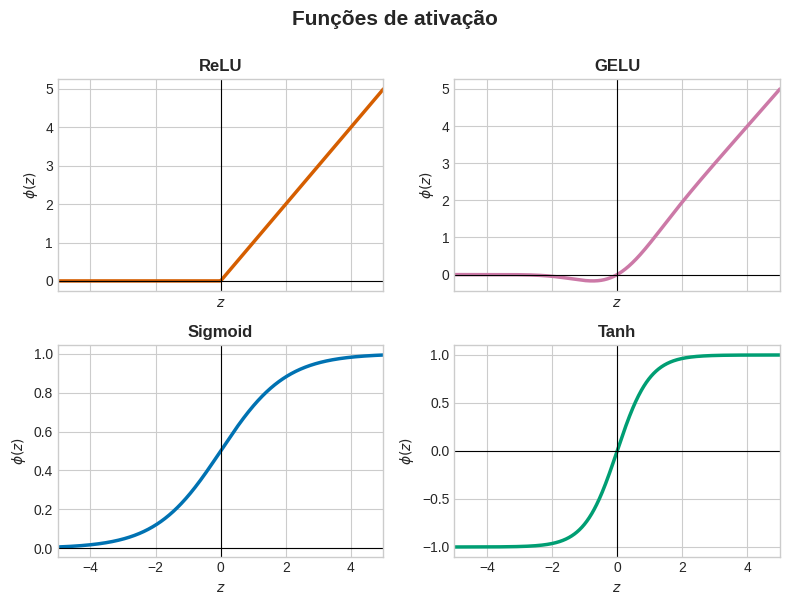

In [21]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

z = np.linspace(-5, 5, 800)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def gelu(z):
    return 0.5 * z * (1 + np.tanh(np.sqrt(2 / np.pi) * (z + 0.044715 * z**3)))

funcoes = [
    ('ReLU', relu(z), '#D55E00'),
    ('GELU', gelu(z), '#CC79A7'),
    ('Sigmoid', sigmoid(z), '#0072B2'),
    ('Tanh', np.tanh(z), '#009E73'),
]

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)

for ax, (nome, valores, cor) in zip(axes.flat, funcoes):
    ax.plot(z, valores, color=cor, linewidth=2.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(nome, fontweight='bold')
    ax.set_xlabel(r'$z$')
    ax.set_ylabel(r'$\phi(z)$')
    ax.set_xlim(-5, 5)

fig.suptitle('Funções de ativação', fontsize=15, fontweight='bold', y=1.0)
fig.tight_layout()
plt.show()

## **5. De perceptrons a MLPs**

Uma **MLP** (*Multilayer Perceptron*) é formada por vários perceptrons organizados em camadas. Considerando $\mathbf{a}^{(0)}=\mathbf{x}$, cada camada $\ell$ calcula:

$$
\mathbf{z}^{(\ell)}=
\mathbf{W}^{(\ell)}\mathbf{a}^{(\ell-1)}
+
\mathbf{b}^{(\ell)},
$$

$$
\mathbf{a}^{(\ell)}=
\phi^{(\ell)}\left(\mathbf{z}^{(\ell)}\right).
$$

Ao final, a última camada fornece a previsão:

$$
\hat{\mathbf{y}} = \mathbf{a}^{(L)}.
$$

Assim, uma rede neural pode ser entendida como uma composição de funções:

$$
\hat{\mathbf{y}}
=
f_L\circ f_{L-1}\circ\cdots\circ f_1(\mathbf{x}).
$$

## **6. Camadas de uma rede neural**

Uma arquitetura MLP possui normalmente três tipos de camada:

- **Camada de entrada:** recebe as variáveis do problema. Por exemplo, $(x,t)$.
- **Camadas escondidas** (*hidden layers*): realizam as transformações intermediárias.
- **Camada de saída:** fornece a variável prevista, por exemplo $\hat{T}$, $\hat{u}$ ou $(\hat{H},\hat{V})$.

Uma representação compacta de uma rede pode ser:

$$
(x,t) \rightarrow [32] \rightarrow [32] \rightarrow [32] \rightarrow \hat{T}.
$$

Os números entre colchetes indicam o número de neurônios em cada camada escondida. A camada de entrada não realiza uma transformação aprendida; ela apenas entrega as variáveis à primeira camada parametrizada.

---

## **7. Redes totalmente conectadas e redes profundas**

Uma rede **totalmente conectada** (*fully connected network*, FCN), também chamada de rede densa, conecta cada neurônio de uma camada a todos os neurônios da camada seguinte.

Se uma camada possui $n_{\text{in}}$ entradas e a seguinte possui $n_{\text{out}}$ neurônios, então essa ligação contém:

$$
n_{\text{in}}n_{\text{out}}
$$

pesos e $n_{\text{out}}$ vieses.

Uma rede é chamada de **profunda** (*deep*) quando possui múltiplas camadas escondidas. Não existe um número universal de camadas que define uma rede como profunda; o termo enfatiza a existência de várias transformações sucessivas.

Mais camadas e mais neurônios aumentam a capacidade de representação da rede, mas também aumentam o número de parâmetros, o custo computacional e a dificuldade de treinamento.

## **8. Forward pass: o caminho da previsão**

O **forward pass** é o caminho direto da informação: entrada $\rightarrow$ camadas escondidas $\rightarrow$ previsão.

Para uma rede com uma camada escondida:

$$
\mathbf{h}=
\phi(\mathbf{W}_1\mathbf{x}+\mathbf{b}_1),
$$

$$
\hat{\mathbf{y}}=
\mathbf{W}_2\mathbf{h}+\mathbf{b}_2.
$$

Em problemas de regressão, como prever temperatura, deslocamento ou velocidade, é frequente usar uma saída linear:

$$
\hat{y}=z^{(L)},
$$

pois a variável prevista não precisa estar limitada ao intervalo $[0,1]$.

## **9. Função de perda e erro quadrático médio**

Depois de produzir uma previsão, a rede precisa medir quão distante ela está da referência. A **função de perda** (*loss function*) transforma esse erro em um único número que será minimizado.

Para regressão, uma escolha muito comum é o erro quadrático médio (*Mean Squared Error*, MSE):

$$
\mathcal{L}_{\text{MSE}}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
y_i-\hat{y}_i
\right)^2.
$$

O quadrado impede que erros positivos e negativos se cancelem e penaliza mais fortemente erros grandes.

Para dados de temperatura, por exemplo:

$$
\mathcal{L}_{\text{dados}}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left[
T(x_i,t_i)-\hat{T}(x_i,t_i)
\right]^2.
$$

Em classificação, outras perdas são mais apropriadas, como a entropia cruzada. Nesta disciplina, entretanto, o MSE será a referência mais natural, pois os problemas de interesse envolvem aproximação de campos contínuos.

## **10. O problema de treinamento**

Treinar uma rede significa encontrar pesos e vieses que minimizem a perda:

$$
\boldsymbol{\theta}^{*}
=
\arg\min_{\boldsymbol{\theta}}
\mathcal{L}(\boldsymbol{\theta}).
$$

O vetor $\boldsymbol{\theta}$ reúne todos os pesos e vieses da rede. Como existem muitos parâmetros, podemos imaginar a perda como uma superfície em um espaço de alta dimensão. O treinamento procura uma região de perda baixa nessa superfície.

---

## **11. Gradiente descendente e taxa de aprendizagem**

O gradiente da perda indica a direção de maior crescimento local:

$$\nabla_{\boldsymbol{\theta}}\mathcal{L}.$$

Para reduzir a perda, atualizamos os parâmetros na direção oposta:

$$
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \eta \nabla_{\boldsymbol{\theta}} \mathcal{L}(\boldsymbol{\theta}_k),
$$

em que $\eta$ é a **taxa de aprendizagem** (*learning rate*).

A taxa de aprendizagem controla o tamanho de cada passo:

- valor muito alto: a otimização pode oscilar ou divergir;
- valor muito baixo: o treinamento se torna excessivamente lento;
- valor adequado: a perda tende a diminuir de forma estável.

> **Literatura Recomendada**  
Vídeo: [Statquest: Gradiente Descendente](https://youtu.be/sDv4f4s2SB8?si=wD0boE2D6IvO7fip)

---

In [9]:
!pip install plotly

In [25]:
import numpy as np
import plotly.graph_objects as go

# ==========================================
# 1. Lógica do Gradiente (Idêntica)
# ==========================================
def perda_paraboloide(theta):
    return 0.5 * (theta[0]**2 + theta[1]**2)

def gradiente_paraboloide(theta):
    return theta.copy()

ponto = np.array([3.0, 3.0])
trajetoria = [ponto.copy()]
taxa = 0.15

for _ in range(15):
    ponto = ponto - taxa * gradiente_paraboloide(ponto)
    trajetoria.append(ponto.copy())

trajetoria = np.array(trajetoria)

# Malha para construir a superfície
eixo = np.linspace(-3.2, 3.2, 100)
Theta_1, Theta_2 = np.meshgrid(eixo, eixo)
Loss = 0.5 * (Theta_1**2 + Theta_2**2)
Loss_traj = 0.5 * (trajetoria[:, 0]**2 + trajetoria[:, 1]**2)

# ==========================================
# 2. Construção do Gráfico Interativo 3D
# ==========================================
fig = go.Figure()

# A. Adicionando a superfície da "tigela"
fig.add_trace(go.Surface(
    x=Theta_1,
    y=Theta_2,
    z=Loss,
    colorscale='IceFire', # Mapa de cores bonito e contrastante
    opacity=0.75,         # Transparência para ver a trajetória através da borda
    showscale=False,
    name='Superfície de Perda',
    contours=dict(z=dict(show=True, usecolormap=True, highlightcolor="limegreen", project_z=True)) # Curvas de nível na base!
))

# B. Adicionando a linha da trajetória de otimização
fig.add_trace(go.Scatter3d(
    x=trajetoria[:, 0],
    y=trajetoria[:, 1],
    z=Loss_traj + 0.1, # Leve deslocamento para a linha não "afundar" na superfície
    mode='lines+markers',
    marker=dict(size=5, color='#D62828'),
    line=dict(color='#D62828', width=6),
    name='Passos de Otimização'
))

# C. Ponto de Início
fig.add_trace(go.Scatter3d(
    x=[trajetoria[0, 0]],
    y=[trajetoria[0, 1]],
    z=[Loss_traj[0] + 0.1],
    mode='markers',
    marker=dict(size=8, color='#F77F00', line=dict(color='black', width=2)),
    name='Início'
))

# D. Ponto de Mínimo (Alvo)
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=8, color='#003049', line=dict(color='white', width=2)),
    name='Mínimo Global'
))

# ==========================================
# 3. Ajustes visuais da câmera e layout
# ==========================================
fig.update_layout(
    title=dict(
        text='Gradiente Descendente: O Problema dos Mínimos Locais (Paraboloide)',
        font=dict(size=18),
        x=0.5,
        y=0.97 # Joga o título bem para o topo
    ),
    scene=dict(
        xaxis_title='Theta 1',
        yaxis_title='Theta 2',
        #zaxis_title='Perda L',

        # 1. APROXIMA A CÂMERA (vetores menores dão mais zoom)
        camera=dict(eye=dict(x=1.1, y=-1.1, z=0.75)),

        # 2. AJUSTA A PROPORÇÃO (achata levemente em Z para otimizar espaço)
        aspectratio=dict(x=1.2, y=1.2, z=0.8)
    ),
    width=950,
    height=450,

    # 3. ZERA AS MARGENS LATERAIS E INFERIORES
    margin=dict(l=0, r=0, b=0, t=40),

    legend=dict(
        x=0.02, y=0.96,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='black',
        borderwidth=1
    )
)

fig.show()

In [18]:
import numpy as np
import plotly.graph_objects as go

def ackley(x, y):
    """Função de Ackley bidimensional clássica."""
    termo1 = -20.0 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2)))
    termo2 = -np.exp(0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y)))
    return termo1 + termo2 + np.e + 20.0

def gradiente_numerico(f, x, y, h=1e-5):
    """Calcula o gradiente usando diferenças finitas centrais."""
    df_dx = (f(x + h, y) - f(x - h, y)) / (2 * h)
    df_dy = (f(x, y + h) - f(x, y - h)) / (2 * h)
    return np.array([df_dx, df_dy])

# ==========================================
# 1. Simulação do Gradiente Descendente
# ==========================================
taxa_aprendizado = 0.03
passos = 40

# Três pontos estrategicamente escolhidos para mostrar diferentes destinos
pontos_iniciais = [
    np.array([2.1, 2.1]),   # Vai cair em um mínimo local distante
    np.array([-2.5, 1.2]),  # Vai cair em outro mínimo local
    np.array([-0.4, -0.3])  # Próximo o suficiente para atingir o mínimo global
]

cores = ['#D62828', '#F77F00', '#00F5D4']
nomes = ['Preso no Mínimo Local A', 'Preso no Mínimo Local B', 'Alcançou Mínimo Global']

trajetorias = []
losses_trajetorias = []

for pt in pontos_iniciais:
    ponto_atual = pt.copy()
    traj = [ponto_atual.copy()]
    loss = [ackley(*ponto_atual)]

    for _ in range(passos):
        grad = gradiente_numerico(ackley, *ponto_atual)
        ponto_atual = ponto_atual - taxa_aprendizado * grad
        traj.append(ponto_atual.copy())
        loss.append(ackley(*ponto_atual))

    trajetorias.append(np.array(traj))
    losses_trajetorias.append(np.array(loss))

# ==========================================
# 2. Construção do Gráfico Interativo
# ==========================================
eixo = np.linspace(-3.5, 3.5, 150)
X, Y = np.meshgrid(eixo, eixo)
Z = ackley(X, Y)

fig = go.Figure()

# Superfície da Função de Ackley
fig.add_trace(go.Surface(
    x=X, y=Y, z=Z,
    colorscale='Viridis',
    opacity=0.6, # Transparência essencial para ver as bolinhas no fundo das "crateras"
    showscale=False,
    name='Superfície Ackley',
    contours=dict(z=dict(show=True, usecolormap=True, project_z=True))
))

# Plotando as 3 trajetórias
for i in range(3):
    traj = trajetorias[i]
    loss = losses_trajetorias[i]

    # Linha e passos
    fig.add_trace(go.Scatter3d(
        x=traj[:, 0], y=traj[:, 1], z=loss + 0.15,
        mode='lines+markers',
        marker=dict(size=4, color=cores[i]),
        line=dict(color=cores[i], width=5),
        name=nomes[i]
    ))

    # Marcador de Início (maior)
    fig.add_trace(go.Scatter3d(
        x=[traj[0, 0]], y=[traj[0, 1]], z=[loss[0] + 0.15],
        mode='markers',
        marker=dict(size=7, color=cores[i], line=dict(color='black', width=2)),
        showlegend=False
    ))

# Marcador do Mínimo Global Absoluto
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=8, color='white', line=dict(color='black', width=2)),
    name='Mínimo Global Verdadeiro (0,0)'
))

fig.update_layout(
    title=dict(
        text='Gradiente Descendente: O Problema dos Mínimos Locais (Função de Ackley)',
        font=dict(size=18),
        x=0.5,
        y=0.97 # Joga o título bem para o topo
    ),
    scene=dict(
        xaxis_title='Theta 1',
        yaxis_title='Theta 2',
        zaxis_title='Perda L',

        # 1. APROXIMA A CÂMERA (vetores menores dão mais zoom)
        camera=dict(eye=dict(x=1.1, y=-1.1, z=0.75)),

        # 2. AJUSTA A PROPORÇÃO (achata levemente em Z para otimizar espaço)
        aspectratio=dict(x=1.2, y=1.2, z=0.8)
    ),
    width=950,
    height=500,

    # 3. ZERA AS MARGENS LATERAIS E INFERIORES
    margin=dict(l=0, r=0, b=0, t=40),

    legend=dict(
        x=0.02, y=0.96,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='black',
        borderwidth=1
    )
)

fig.show()

No gráfico, cada ponto $(\theta_1,\theta_2)$ representa uma possível escolha de dois parâmetros. As setas brancas indicam a direção de descida local, isto é, $-\nabla\mathcal{L}$. Em uma rede real, existem centenas, milhares ou milhões de parâmetros; a lógica matemática, porém, é a mesma.

## **12. Regra da cadeia e retropropagação**

Como uma rede é uma composição de funções, usamos a **regra da cadeia** para descobrir como cada peso influencia a perda.

Se

$$
\mathcal{L}=\mathcal{L}(a), \qquad a=\phi(z), \qquad z=wx+b,
$$

então

$$
\frac{\partial\mathcal{L}}{\partial w} = \frac{\partial\mathcal{L}}{\partial a} \frac{\partial a}{\partial z} \frac{\partial z}{\partial w}.
$$

Como

$$\frac{\partial z}{\partial w}=x,$$

temos

$$
\frac{\partial\mathcal{L}}{\partial w} = \frac{\partial\mathcal{L}}{\partial a} \frac{\partial a}{\partial z}x.
$$

A **retropropagação** (*backpropagation*) é o algoritmo eficiente que aplica a regra da cadeia da saída em direção à entrada, obtendo os gradientes de todos os pesos e vieses.

É importante separar os papéis:

- **forward pass:** calcula previsão e perda;
- **backward pass / backpropagation:** calcula gradientes;
- **otimizador:** usa os gradientes para atualizar os parâmetros.

> **Literatura Recomendada**  
Vídeo: [Statquest: Regra da Cadeia](https://youtu.be/wl1myxrtQHQ?si=UOtzohgBVZRo3q-x)  
Vídeo: [Statquest: Retropropagação](https://youtu.be/IN2XmBhILt4?si=sYnUkTV2UiU86nqz)

---

## **13. Diferenciação automática**

A diferenciação automática (*automatic differentiation*, AD) é o mecanismo usado por bibliotecas como PyTorch, TensorFlow e JAX para calcular derivadas por meio da regra da cadeia aplicada às operações realizadas pelo programa.

Ela não é diferenciação simbólica, em que se manipula uma expressão no papel, nem diferença finita, em que a derivada é aproximada por algo como

$$
\frac{df}{dx}\approx\frac{f(x+h)-f(x)}{h}.
$$

Em uma rede convencional, a diferenciação automática permite obter os gradientes da perda em relação aos parâmetros:

$$
\frac{\partial\mathcal{L}}{\partial \theta}.
$$

Posteriormente, essa mesma ferramenta permitirá calcular derivadas da saída da rede em relação às entradas, como

$$
\frac{\partial \hat{T}}{\partial t},
\qquad
\frac{\partial \hat{T}}{\partial x},
\qquad
\frac{\partial^2\hat{T}}{\partial x^2}.
$$

---

## **14. Otimizadores: Adam e L-BFGS**

O gradiente descendente básico atualiza diretamente os parâmetros usando o gradiente. Os otimizadores introduzem estratégias adicionais para tornar essa atualização mais eficiente.

### **Adam**

O Adam combina uma média dos gradientes com uma média dos gradientes ao quadrado. Em forma simplificada:

$$
\mathbf{m}_k = \beta_1\mathbf{m}_{k-1} + (1-\beta_1)\mathbf{g}_k,
$$

$$
\mathbf{v}_k = \beta_2\mathbf{v}_{k-1} + (1-\beta_2)\mathbf{g}_k^2,
$$

em que $\mathbf{g}_k=\nabla_{\theta}\mathcal{L}$. A atualização é aproximadamente:

$$
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_{k} - \eta
\frac{\hat{\mathbf{m}}_k} {\sqrt{\hat{\mathbf{v}}_k}+\epsilon}.
$$

O Adam adapta o tamanho do passo para cada parâmetro e, por isso, costuma ser uma boa escolha para iniciar o treinamento.

### **L-BFGS**

O L-BFGS é um método *quasi-Newton*. Ele utiliza um histórico de gradientes e atualizações anteriores para estimar informações de curvatura da perda, sem armazenar uma matriz Hessiana completa.

Em problemas de menor porte, ele pode refinar bem uma solução já encontrada. Por essa razão, é comum encontrar estratégias que usam Adam inicialmente e L-BFGS em uma etapa posterior de refinamento.

## **15. Inicialização de pesos: Glorot/Xavier**

Antes do treinamento, os pesos precisam receber valores iniciais. Inicializar todos os pesos com zero não é adequado, pois neurônios de uma mesma camada receberiam exatamente o mesmo gradiente e aprenderiam a mesma representação.

A inicialização de Glorot/Xavier busca manter a escala das ativações e dos gradientes relativamente estável ao longo das camadas. Para uma distribuição uniforme:

$$
W \sim \mathcal{U} \left(-\sqrt{\frac{6}{n_{\text{in}}+n_{\text{out}}}}, \, \sqrt{\frac{6}{n_{\text{in}}+n_{\text{out}}}} \right).
$$

Ela é especialmente associada a ativações suaves, como $\tanh$. Uma inicialização inadequada pode fazer ativações ou gradientes crescerem demais, desaparecerem ou conduzir a trajetórias de treinamento muito diferentes.

## **16. Épocas, batches, iterações e passos de otimização**

Estes termos descrevem como os dados são apresentados à rede durante o treinamento:

- **Amostra:** um exemplo individual, como $(x_i,t_i,T_i)$.
- **Batch:** grupo de amostras processadas conjuntamente.
- **Iteração:** uma atualização dos parâmetros usando um batch.
- **Época:** uma passagem completa por todo o conjunto de treinamento.
- **Passo de otimização:** nome geral para uma atualização dos parâmetros.

Se existem $N=1000$ amostras e o batch size é $100$, uma época contém

$$
\frac{1000}{100}=10
$$

iterações.

Quando usamos o conjunto de dados inteiro em cada atualização (*full batch*), uma época e uma iteração podem coincidir. Por isso, em gráficos de treinamento, especialmente quando diferentes otimizadores são usados, o rótulo **Optimization step** pode ser mais preciso que simplesmente “época”.

## **17. Dados de treinamento, validação e teste**

Em aprendizado supervisionado, é comum separar os dados em três conjuntos:

- **treinamento:** usado para ajustar pesos e vieses;
- **validação:** usado para acompanhar o desempenho durante o treinamento e escolher configurações;
- **teste:** usado apenas para avaliar o modelo final em dados não vistos.

Essa separação permite avaliar a **generalização**: não basta reduzir o erro no conjunto de treinamento; o modelo deve apresentar bom desempenho também em exemplos novos.

Dois comportamentos indesejados são:

- **underfitting:** a rede é simples demais, foi pouco treinada ou não aprendeu a relação;
- **overfitting:** a rede se ajusta excessivamente aos dados de treinamento, inclusive a ruídos, e perde desempenho em dados novos.

## **18. Normalização e hiperparâmetros**

Variáveis com escalas muito diferentes podem tornar o treinamento mais difícil. Por isso, é comum normalizar as entradas, por exemplo para o intervalo $[-1,1]$:

$$
\tilde{x} = 2\frac{x-x_{\min}}{x_{\max}-x_{\min}}-1.
$$

Também é importante distinguir:

- **parâmetros aprendidos:** pesos e vieses, alterados pelo otimizador;
- **hiperparâmetros:** escolhas definidas pelo usuário, como número de camadas, neurônios, ativação, taxa de aprendizagem, batch size, inicialização e número de épocas.

A escolha de hiperparâmetros altera a capacidade da rede, a estabilidade do treinamento e o custo computacional.

## **19. Exemplo mínimo de uma MLP em PyTorch**

O bloco abaixo apenas constrói uma MLP para regressão. A entrada possui duas variáveis, as camadas escondidas possuem 32 neurônios e a saída possui um valor. A última camada é linear, como é usual quando queremos prever uma grandeza contínua.

In [3]:
import torch
import torch.nn as nn

torch.manual_seed(0)

modelo = nn.Sequential(
    nn.Linear(2, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 1),
)

numero_parametros = sum(p.numel() for p in modelo.parameters())

print(modelo)
print(f'\nNúmero de parâmetros treináveis: {numero_parametros}')

# Exemplo de forward pass para três pares de entrada (x, t).
entradas = torch.tensor([[0.0, 0.0], [0.5, 0.2], [1.0, 1.0]], dtype=torch.float32)
previsoes = modelo(entradas)

print('\nEntradas:')
print(entradas)
print('\nPrevisões iniciais (antes do treinamento):')
print(previsoes.detach())

Sequential(
  (0): Linear(in_features=2, out_features=32, bias=True)
  (1): Tanh()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): Tanh()
  (4): Linear(in_features=32, out_features=1, bias=True)
)

Número de parâmetros treináveis: 1185

Entradas:
tensor([[0.0000, 0.0000],
        [0.5000, 0.2000],
        [1.0000, 1.0000]])

Previsões iniciais (antes do treinamento):
tensor([[-0.0810],
        [-0.1259],
        [-0.1049]])


## **20. Síntese da aula**

Uma MLP recebe entradas, realiza transformações lineares seguidas de ativações não lineares e produz uma previsão. Seus pesos e vieses são ajustados para reduzir uma função de perda. Esse ajuste depende de gradientes, calculados pela regra da cadeia por meio da retropropagação e da diferenciação automática.

Em forma resumida:

$$
\boxed{
\text{dados de entrada}
\rightarrow
\text{MLP}
\rightarrow
\text{previsão}
\rightarrow
\text{loss}
\rightarrow
\text{backpropagation}
\rightarrow
\text{otimizador}
}
$$

As principais ideias a reter são:

1. pesos e vieses definem a função aprendida pela rede;
2. ativações permitem representar relações não lineares;
3. a loss informa quão boa é a previsão;
4. o gradiente mostra como alterar os parâmetros para reduzir a loss;
5. Adam e L-BFGS são estratégias para realizar essas atualizações;
6. inicialização, normalização e hiperparâmetros afetam fortemente o treinamento.

Na próxima etapa do curso, essa mesma estrutura de MLP será usada em problemas governados por equações físicas.